            Hand_Weeding  Weedicide  Water  No_Weeding
Date                                                  
1992-04-01         26.45      56.69   2.12       14.74
1992-09-01         25.04      60.67   2.41       11.88
1993-04-01         22.05      62.60   2.26       13.09
1993-09-01         22.77      62.62   2.57       12.04
1994-04-01         25.91      61.10   2.80       10.20
<class 'pandas.DataFrame'>
DatetimeIndex: 67 entries, 1992-04-01 to 2025-04-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Hand_Weeding  67 non-null     float64
 1   Weedicide     67 non-null     float64
 2   Water         67 non-null     float64
 3   No_Weeding    67 non-null     float64
dtypes: float64(4)
memory usage: 2.6 KB
None


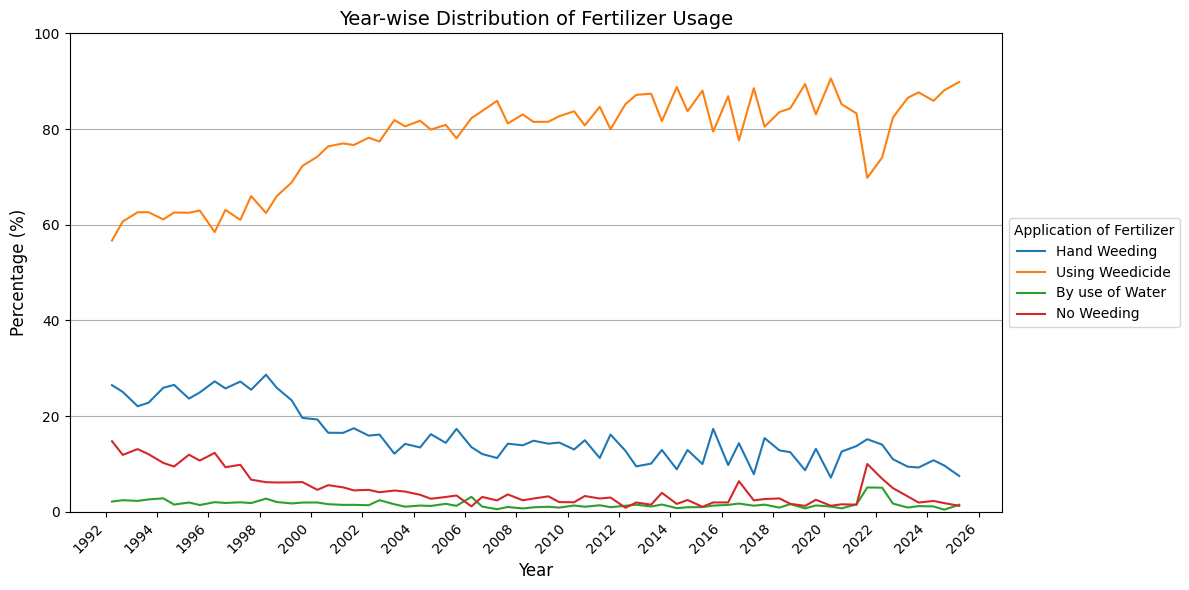

In [4]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_absolute_error, mean_squared_error

mpl.rcParams['figure.figsize'] = (10, 8)
mpl.rcParams['axes.grid'] = False

# =========================================================
# LOAD DATA
# =========================================================
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:, :]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df[['Date',
         'Hand_Weeding', 'Weedicide', 'Water', 'No_Weeding']]
df.set_index('Date', inplace=True)

print(df.head())
print(df.info())

# =========================================================
# PLOT ORIGINAL DATA
# =========================================================
ax = df.plot(figsize=(12, 6))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(0, 100)
plt.xticks(rotation=45)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.legend([
    "Hand Weeding","Using Weedicide","By use of Water","No Weeding"
], title="Application of Fertilizer", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("Year-wise Distribution of Fertilizer Usage", fontsize=14)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [5]:

# =========================================================
# ADF TEST FUNCTION
# =========================================================
def adf_check(series):
    result = adfuller(series.dropna())
    return result[0], result[1]

# =========================================================
# CHECK ORIGINAL STATIONARITY
# =========================================================
print("\nADF TEST RESULTS (ORIGINAL SERIES)")
diff_count = {}

for column in df.columns:
    adf_stat, p_value = adf_check(df[column])
    print(f"\n{column}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")

    d = 0
    temp_series = df[column].copy()
    while adf_check(temp_series)[1] > 0.05:
        temp_series = temp_series.diff().dropna()
        d += 1
        if d == 3:
            break

    diff_count[column] = d
    print(f"  Differencing Needed : {d}")

# =========================================================
# USE SAME DIFFERENCING ORDER
# =========================================================
max_diff = max(diff_count.values())
print(f"\nMaximum Differencing Order : {max_diff}")



ADF TEST RESULTS (ORIGINAL SERIES)

Hand_Weeding
  ADF Statistic : -0.9585
  p-value       : 0.7681
  Differencing Needed : 1

Weedicide
  ADF Statistic : -1.6084
  p-value       : 0.4794
  Differencing Needed : 1

Water
  ADF Statistic : -4.8899
  p-value       : 0.0000
  Differencing Needed : 0

No_Weeding
  ADF Statistic : -4.7542
  p-value       : 0.0001
  Differencing Needed : 0

Maximum Differencing Order : 1


In [6]:

# =========================================================
# DIFFERENCE ALL SERIES
# =========================================================
df_diff = df.copy()
for i in range(max_diff):
    df_diff = df_diff.diff()
df_diff = df_diff.dropna()

# =========================================================
# FINAL STATIONARITY CHECK
# =========================================================
print("\nFINAL STATIONARITY RESULTS")
for column in df_diff.columns:
    adf_stat, p_value = adf_check(df_diff[column])
    print(f"\n{column}")
    print(f"  ADF Statistic : {adf_stat:.4f}")
    print(f"  p-value       : {p_value:.4f}")
    print("  Stationary" if p_value <= 0.05 else "  STILL NOT Stationary")


FINAL STATIONARITY RESULTS

Hand_Weeding
  ADF Statistic : -6.8252
  p-value       : 0.0000
  Stationary

Weedicide
  ADF Statistic : -6.8738
  p-value       : 0.0000
  Stationary

Water
  ADF Statistic : -5.7072
  p-value       : 0.0000
  Stationary

No_Weeding
  ADF Statistic : -1.8744
  p-value       : 0.3442
  STILL NOT Stationary


In [7]:

# =========================================================
# TRAIN TEST SPLIT (80 / 20)
# =========================================================
train_size = int(len(df_diff) * 0.8)
train = df_diff.iloc[:train_size]
test  = df_diff.iloc[train_size:]

print(f"\nTrain Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")


Train Shape : (52, 4)
Test Shape  : (14, 4)


In [8]:
# =========================================================
# ADD JITTER TO AVOID SINGULAR COVARIANCE MATRIX
# =========================================================
np.random.seed(42)
train_jittered = train + np.random.normal(0, 1e-6, train.shape)

# =========================================================
# SAFE LAG SELECTION
# =========================================================
n_obs        = len(train_jittered)
n_vars       = train_jittered.shape[1]
safe_maxlags = max(1, int((n_obs - 1) / (n_vars + 1)))
print(f"\nTrain observations    : {n_obs}")
print(f"Number of variables   : {n_vars}")
print(f"Safe max lags allowed : {safe_maxlags}")

selected_lag = 1
for try_lag in range(safe_maxlags, 0, -1):
    try:
        lag_result   = VAR(train_jittered).select_order(maxlags=try_lag)
        selected_lag = lag_result.selected_orders['aic']
        selected_lag = max(1, selected_lag)
        print(f"\nLag Order Selection:")
        print(lag_result.summary())
        print(f"Selected Lag (AIC) : {selected_lag}")
        break
    except Exception as e:
        print(f"  maxlags={try_lag} failed, trying lower...")
        continue


Train observations    : 52
Number of variables   : 4
Safe max lags allowed : 10
  maxlags=10 failed, trying lower...

Lag Order Selection:
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -8.121      -7.957   0.0002974      -8.060
1      -9.297     -8.478*   9.205e-05      -8.995
2      -9.325      -7.850   9.144e-05      -8.781
3      -9.485      -7.355   8.219e-05      -8.699
4      -9.391      -6.606   0.0001002      -8.364
5      -9.169      -5.729   0.0001500      -7.900
6      -9.826      -5.730   0.0001051      -8.315
7      -10.64      -5.884   7.634e-05      -8.883
8      -11.58      -6.170   6.750e-05      -9.583
9     -13.42*      -7.356  4.819e-05*     -11.18*
-------------------------------------------------
Selected Lag (AIC) : 9


In [9]:
# =========================================================
# FIT VAR MODEL
# =========================================================
var_model  = VAR(train_jittered)
var_result = var_model.fit(selected_lag)




In [10]:

print("\nVAR MODEL SUMMARY")
print(var_result.summary())


VAR MODEL SUMMARY
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 03, Jun, 2026
Time:                     20:59:30
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -7.35599
Nobs:                     43.0000    HQIC:                  -11.1824
Log likelihood:           192.425    FPE:                4.81856e-05
AIC:                     -13.4178    Det(Omega_mle):     4.02190e-06
--------------------------------------------------------------------
Results for equation Hand_Weeding
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.275016         0.539895            0.509           0.610
L1.Hand_Weeding      -235.724908       230.596330           -1.022           0.307
L1.Weedicide         -235.

In [11]:
# =========================================================
# FORECASTING
# =========================================================
forecast_steps  = len(test)
lag_input       = train_jittered.values[-selected_lag:]

forecast_values = var_result.forecast(y=lag_input, steps=forecast_steps)
forecast_df     = pd.DataFrame(
    forecast_values,
    index=test.index,
    columns=test.columns
)

print("\nForecasted Differenced Values")
print(forecast_df.head())


Forecasted Differenced Values
            Hand_Weeding  Weedicide     Water  No_Weeding
Date                                                     
2018-09-01     11.471172 -13.580545  0.923837    1.162919
2019-04-01    -16.158605  14.817657  3.153885   -1.804137
2019-09-01      6.497291  -7.572277 -3.898781    4.996122
2020-04-01     -1.992801   9.357152 -0.809678   -6.592228
2020-09-01     11.009359 -18.642719  2.307650    5.327372


In [12]:
# =========================================================
# INVERSE DIFFERENCING (generalized for any max_diff)
# =========================================================
forecast_restored = forecast_df.copy()

for level in range(max_diff):
    ref = df.copy()
    for _ in range(max_diff - 1 - level):
        ref = ref.diff().dropna()
    last_val = ref.iloc[: train_size + max_diff - 1 - level].iloc[-1]
    forecast_restored = forecast_restored.cumsum() + last_val


In [13]:
# =========================================================
# CLIP & NORMALIZE
# =========================================================
forecast_restored = forecast_restored.clip(lower=0, upper=100)
forecast_restored = forecast_restored.div(
    forecast_restored.sum(axis=1), axis=0
) * 100

print("\nForecasts After Normalization")
print(forecast_restored.head())



Forecasts After Normalization
            Hand_Weeding  Weedicide     Water  No_Weeding
Date                                                     
2018-09-01     26.867248  66.914589  2.404381    3.813781
2019-04-01     10.704046  81.728404  5.558490    2.009060
2019-09-01     17.198389  74.138505  1.658800    7.004306
2020-04-01     15.211471  83.526224  0.849509    0.412796
2020-09-01     26.223589  64.877015  3.157777    5.741619


In [14]:
# =========================================================
# ACTUAL TEST VALUES
# =========================================================
actual_original  = df.iloc[train_size + max_diff:]
actual_original  = actual_original.loc[forecast_restored.index]

In [15]:
# =========================================================
# 1. FORECASTING ACCURACY — MAE, RMSE, NRMSE
# =========================================================
print("\n" + "="*60)
print("1. FORECASTING ACCURACY")
print("="*60)

evaluation_results = []

for column in actual_original.columns:
    actual    = actual_original[column]
    predicted = forecast_restored[column]

    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # NRMSE — normalized by range
    value_range = actual.max() - actual.min()
    nrmse = (rmse / value_range * 100) if value_range != 0 else np.nan

    # MAPE — skip zeros
    nonzero = actual != 0
    mape = np.mean(np.abs(
        (actual[nonzero] - predicted[nonzero]) / actual[nonzero]
    )) * 100 if nonzero.sum() > 0 else np.nan

    evaluation_results.append([column, mae, rmse, nrmse, mape])

    print(f"\n{column}")
    print(f"  MAE   : {mae:.4f}  (percentage points)")
    print(f"  RMSE  : {rmse:.4f}  (percentage points)")
    print(f"  NRMSE : {nrmse:.2f}%")
    print(f"  MAPE  : {mape:.2f}%" if not np.isnan(mape) else "  MAPE  : N/A")

evaluation_df = pd.DataFrame(
    evaluation_results,
    columns=['Variable', 'MAE', 'RMSE', 'NRMSE(%)', 'MAPE(%)']
)
print("\nAccuracy Summary Table:")
print(evaluation_df.to_string(index=False))


1. FORECASTING ACCURACY

Hand_Weeding
  MAE   : 9.0853  (percentage points)
  RMSE  : 11.3677  (percentage points)
  NRMSE : 141.21%
  MAPE  : 87.89%

Weedicide
  MAE   : 10.8798  (percentage points)
  RMSE  : 13.8577  (percentage points)
  NRMSE : 66.69%
  MAPE  : 12.62%

Water
  MAE   : 1.8045  (percentage points)
  RMSE  : 2.1897  (percentage points)
  NRMSE : 47.19%
  MAPE  : 183.46%

No_Weeding
  MAE   : 2.6735  (percentage points)
  RMSE  : 3.1542  (percentage points)
  NRMSE : 36.01%
  MAPE  : 115.67%

Accuracy Summary Table:
    Variable       MAE      RMSE   NRMSE(%)    MAPE(%)
Hand_Weeding  9.085251 11.367703 141.213702  87.885431
   Weedicide 10.879764 13.857707  66.687716  12.622047
       Water  1.804540  2.189696  47.191733 183.458473
  No_Weeding  2.673481  3.154195  36.006792 115.665245


In [16]:
print(actual_original.columns)

Index(['Hand_Weeding', 'Weedicide', 'Water', 'No_Weeding'], dtype='str')


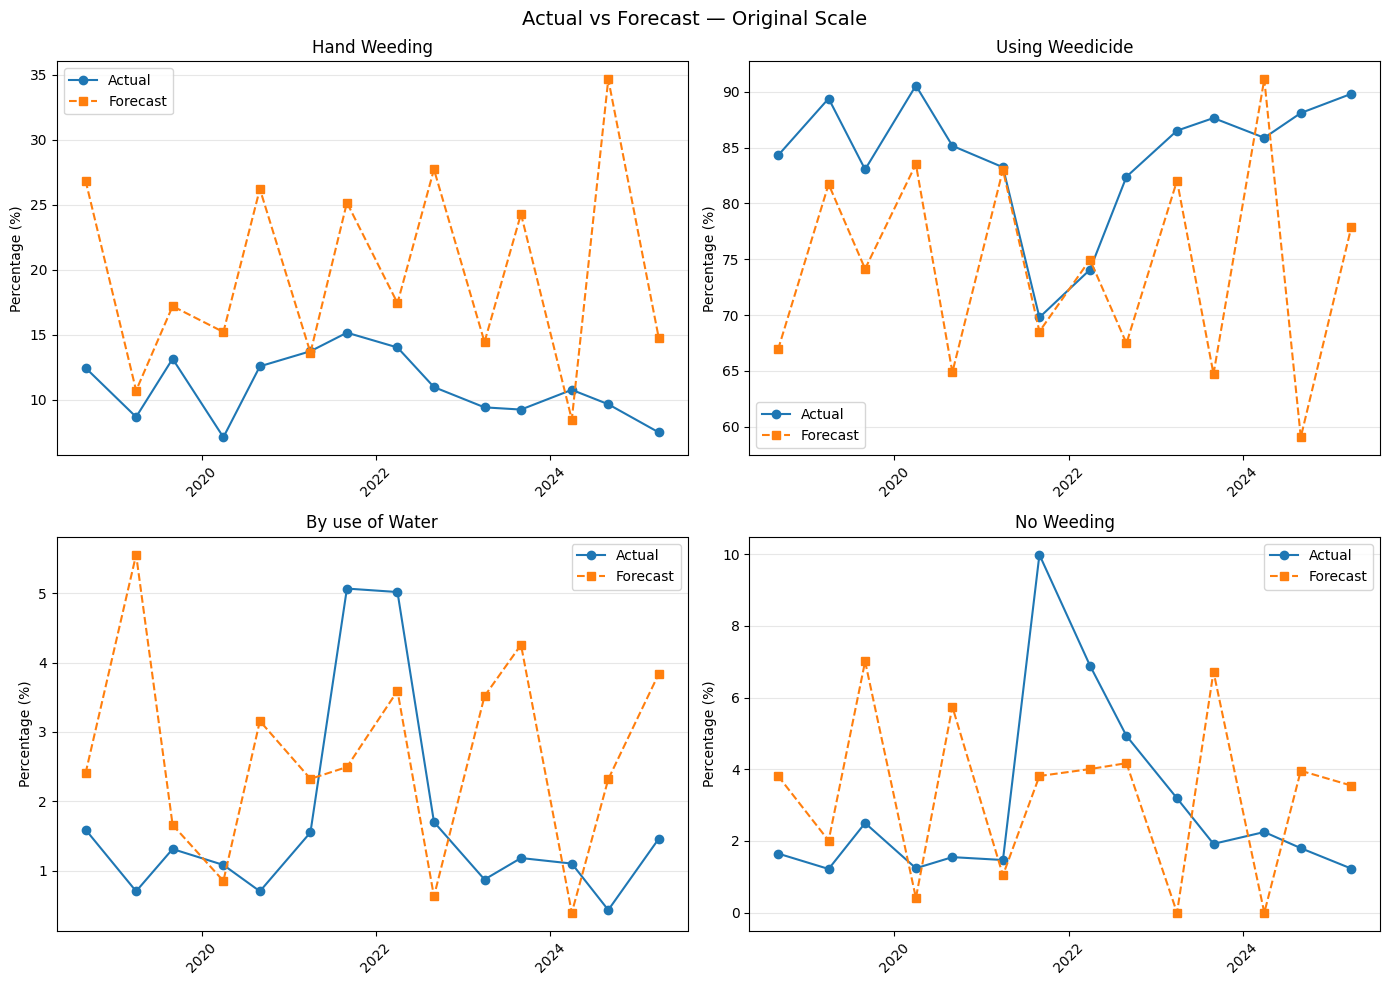

In [17]:
title_map = {
    'Hand_Weeding': "Hand Weeding",
    'Weedicide' : "Using Weedicide", 
    'Water' : "By use of Water",
    'No_Weeding' :"No Weeding"
}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, column in enumerate(actual_original.columns):

    axes[i].plot(actual_original.index,
                 actual_original[column],
                 marker='o',
                 label='Actual')

    axes[i].plot(forecast_restored.index,
                 forecast_restored[column],
                 marker='s',
                 linestyle='--',
                 label='Forecast')

    axes[i].set_title(
        title_map.get(column, column),
        fontsize=12
    )

    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=45)

    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle("Actual vs Forecast — Original Scale", fontsize=14)
plt.tight_layout()
plt.show()


2. GRANGER CAUSALITY ANALYSIS
Using lag = 9 (same as VAR model)

Weedicide            → Hand_Weeding         | F=2.9632  p=0.0161  **
Water                → Hand_Weeding         | F=1.1234  p=0.3846  ns
No_Weeding           → Hand_Weeding         | F=2.4897  p=0.0360  **
Hand_Weeding         → Weedicide            | F=2.4556  p=0.0382  **
Water                → Weedicide            | F=1.6927  p=0.1458  ns
No_Weeding           → Weedicide            | F=1.9432  p=0.0937  *
Hand_Weeding         → Water                | F=1.0331  p=0.4433  ns
Weedicide            → Water                | F=0.7067  p=0.6972  ns
No_Weeding           → Water                | F=0.7857  p=0.6317  ns
Hand_Weeding         → No_Weeding           | F=1.7822  p=0.1245  ns
Weedicide            → No_Weeding           | F=1.9331  p=0.0954  *
Water                → No_Weeding           | F=0.8656  p=0.5673  ns

Granger Causality Summary:
       Cause       Effect  F-statistic  p-value Significance
   Weedicide Hand_W

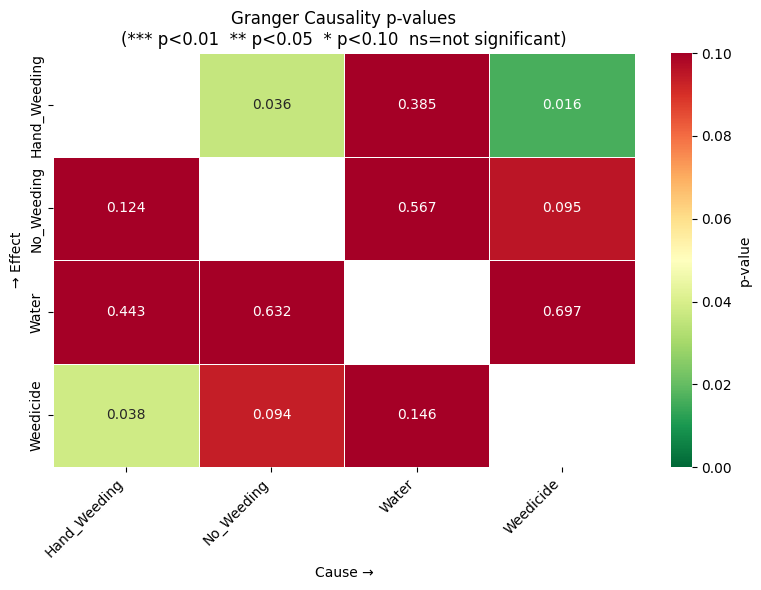

In [18]:
# =========================================================
# 2. GRANGER CAUSALITY — FULL MATRIX
# =========================================================
print("\n" + "="*60)
print("2. GRANGER CAUSALITY ANALYSIS")
print("="*60)
print(f"Using lag = {selected_lag} (same as VAR model)\n")

columns      = train_jittered.columns.tolist()
gc_results   = []

for caused in columns:
    for cause in columns:
        if cause == caused:
            continue
        try:
            test_data = train_jittered[[caused, cause]]
            gc_test   = grangercausalitytests(
                test_data,
                maxlag=selected_lag,
                verbose=False
            )
            p_value = gc_test[selected_lag][0]['ssr_ftest'][1]
            f_stat  = gc_test[selected_lag][0]['ssr_ftest'][0]

            if p_value <= 0.01:
                sig = "***"
            elif p_value <= 0.05:
                sig = "**"
            elif p_value <= 0.10:
                sig = "*"
            else:
                sig = "ns"

            gc_results.append({
                'Cause':        cause,
                'Effect':       caused,
                'F-statistic':  round(f_stat, 4),
                'p-value':      round(p_value, 4),
                'Significance': sig
            })

            print(f"{cause:20s} → {caused:20s} | "
                  f"F={f_stat:.4f}  p={p_value:.4f}  {sig}")

        except Exception as e:
            print(f"  Skipped {cause} → {caused} : {e}")

gc_df = pd.DataFrame(gc_results)

print("\nGranger Causality Summary:")
print(gc_df.to_string(index=False))

# --- Heatmap ---
pivot_p = gc_df.pivot(index='Effect', columns='Cause', values='p-value')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot_p,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=0,
    vmax=0.10,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'p-value'}
)
ax.set_title(
    "Granger Causality p-values\n"
    "(*** p<0.01  ** p<0.05  * p<0.10  ns=not significant)",
    fontsize=12
)
ax.set_xlabel("Cause →")
ax.set_ylabel("→ Effect")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


3. IMPULSE RESPONSE FUNCTIONS (IRF)
IRF plot: shows how a shock in one variable
affects all other variables over time.



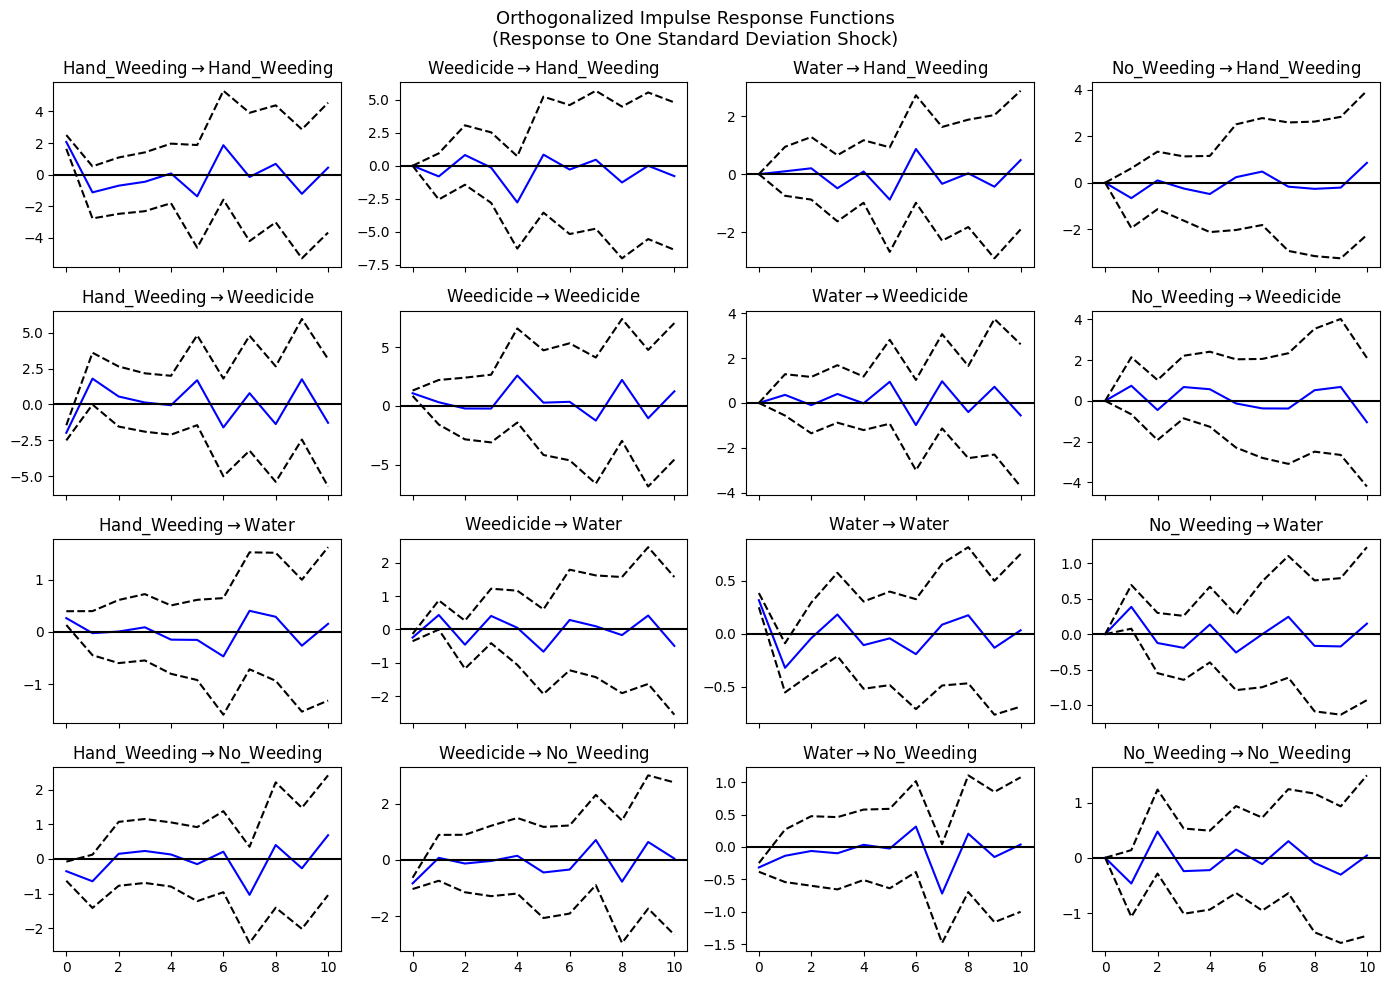

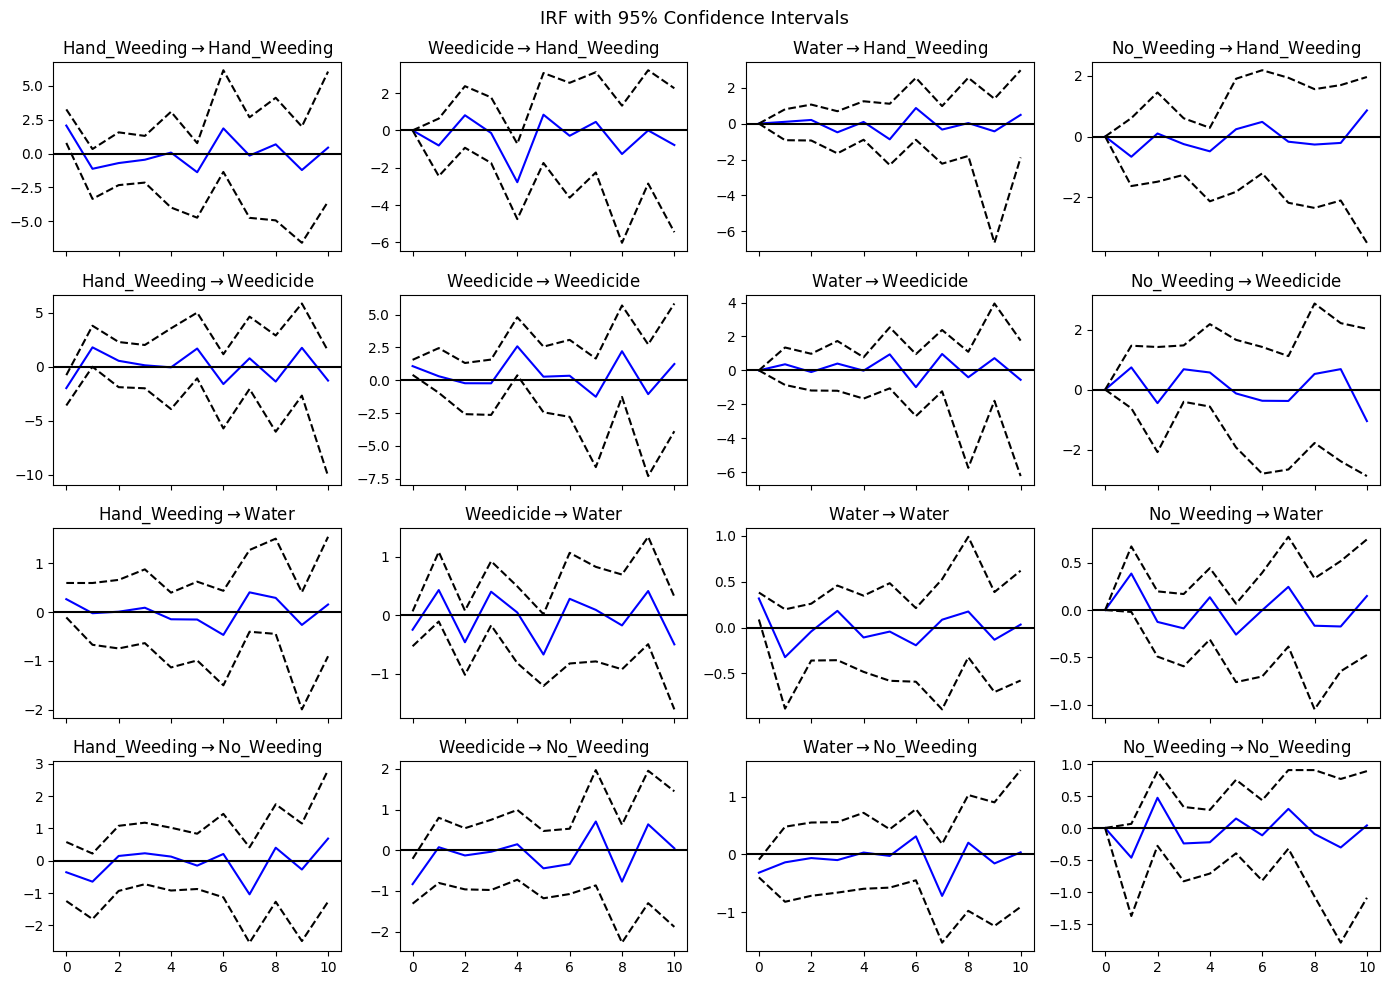

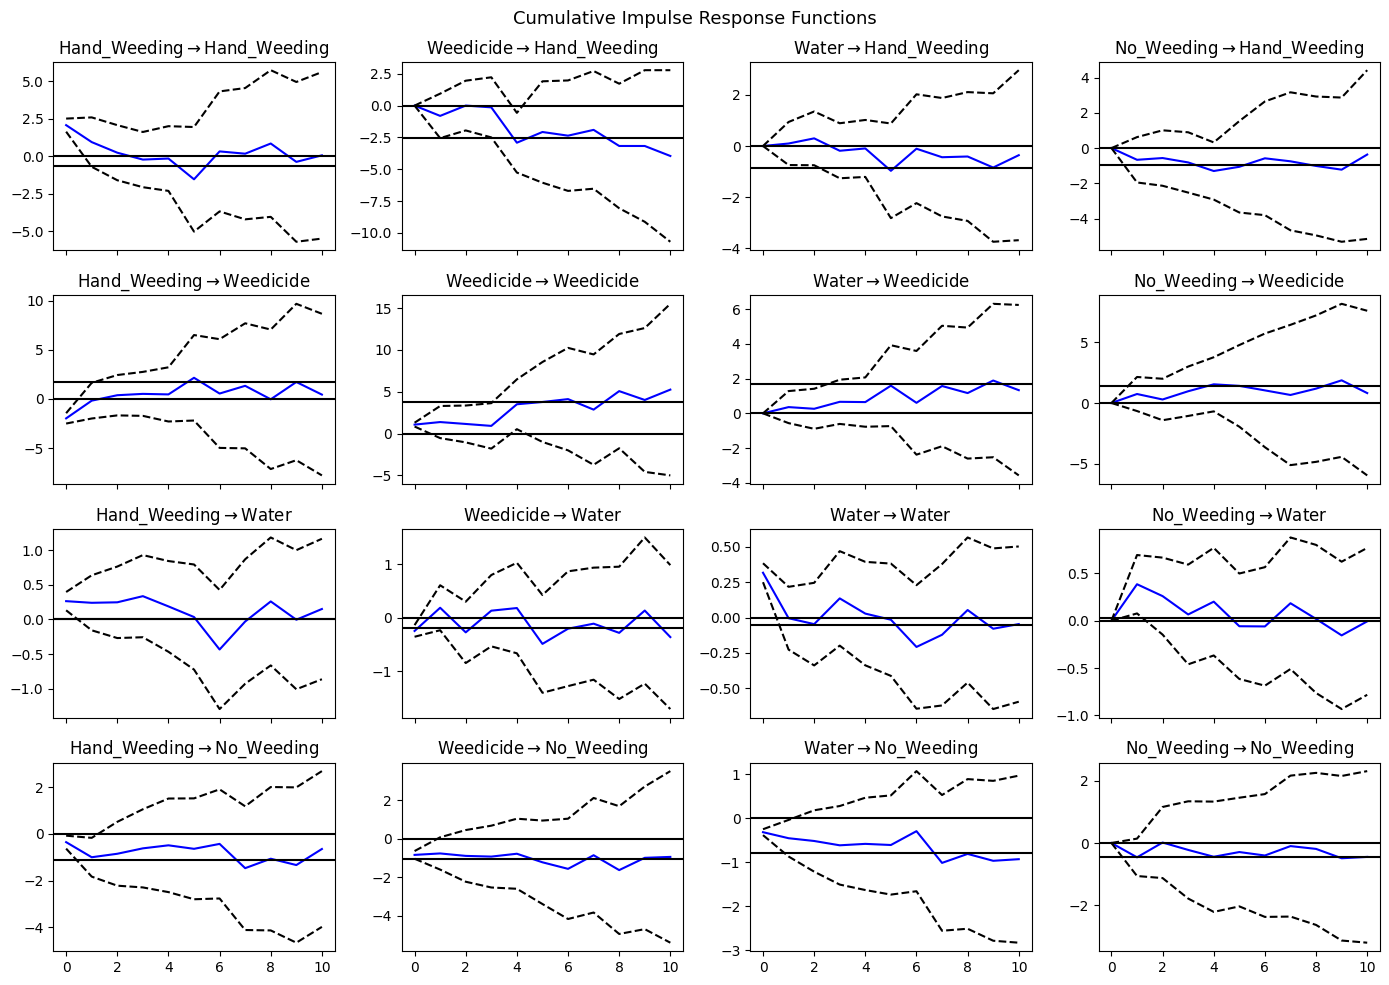

In [19]:

# =========================================================
# 3. IMPULSE RESPONSE FUNCTIONS (IRF)
# =========================================================
print("\n" + "="*60)
print("3. IMPULSE RESPONSE FUNCTIONS (IRF)")
print("="*60)

irf_periods = 10

irf = var_result.irf(periods=irf_periods)

print("IRF plot: shows how a shock in one variable")
print("affects all other variables over time.\n")

# Plot IRF
irf.plot(
    orth=True,
    figsize=(14, 10)
)
plt.suptitle(
    "Orthogonalized Impulse Response Functions\n"
    "(Response to One Standard Deviation Shock)",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Plot IRF with confidence intervals
irf.plot(
    orth=True,
    stderr_type='mc',
    repl=100,
    figsize=(14, 10)
)
plt.suptitle(
    "IRF with 95% Confidence Intervals",
    fontsize=13
)
plt.tight_layout()
plt.show()

# Cumulative IRF
irf.plot_cum_effects(
    orth=True,
    figsize=(14, 10)
)
plt.suptitle(
    "Cumulative Impulse Response Functions",
    fontsize=13
)
plt.tight_layout()
plt.show()


4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
FEVD: shows what % of each variable's forecast
error variance is explained by each variable.

FEVD Shape: (4, 10, 4)

--------------------------------------------------
FEVD for Hand_Weeding
--------------------------------------------------
        Hand_Weeding  Weedicide  Water  No_Weeding
Period                                            
1             100.00       0.00   0.00        0.00
2              83.43       9.80   0.14        6.63
3              76.97      16.65   0.64        5.74
4              74.64      15.84   3.41        6.12
5              38.34      55.27   1.80        4.59
6              41.35      49.21   5.36        4.08
7              47.89      40.40   7.44        4.27
8              47.26      40.64   7.78        4.32
9              45.23      43.37   7.16        4.24
10             47.73      40.75   7.38        4.14

--------------------------------------------------
FEVD for Weedicide
--------------------------

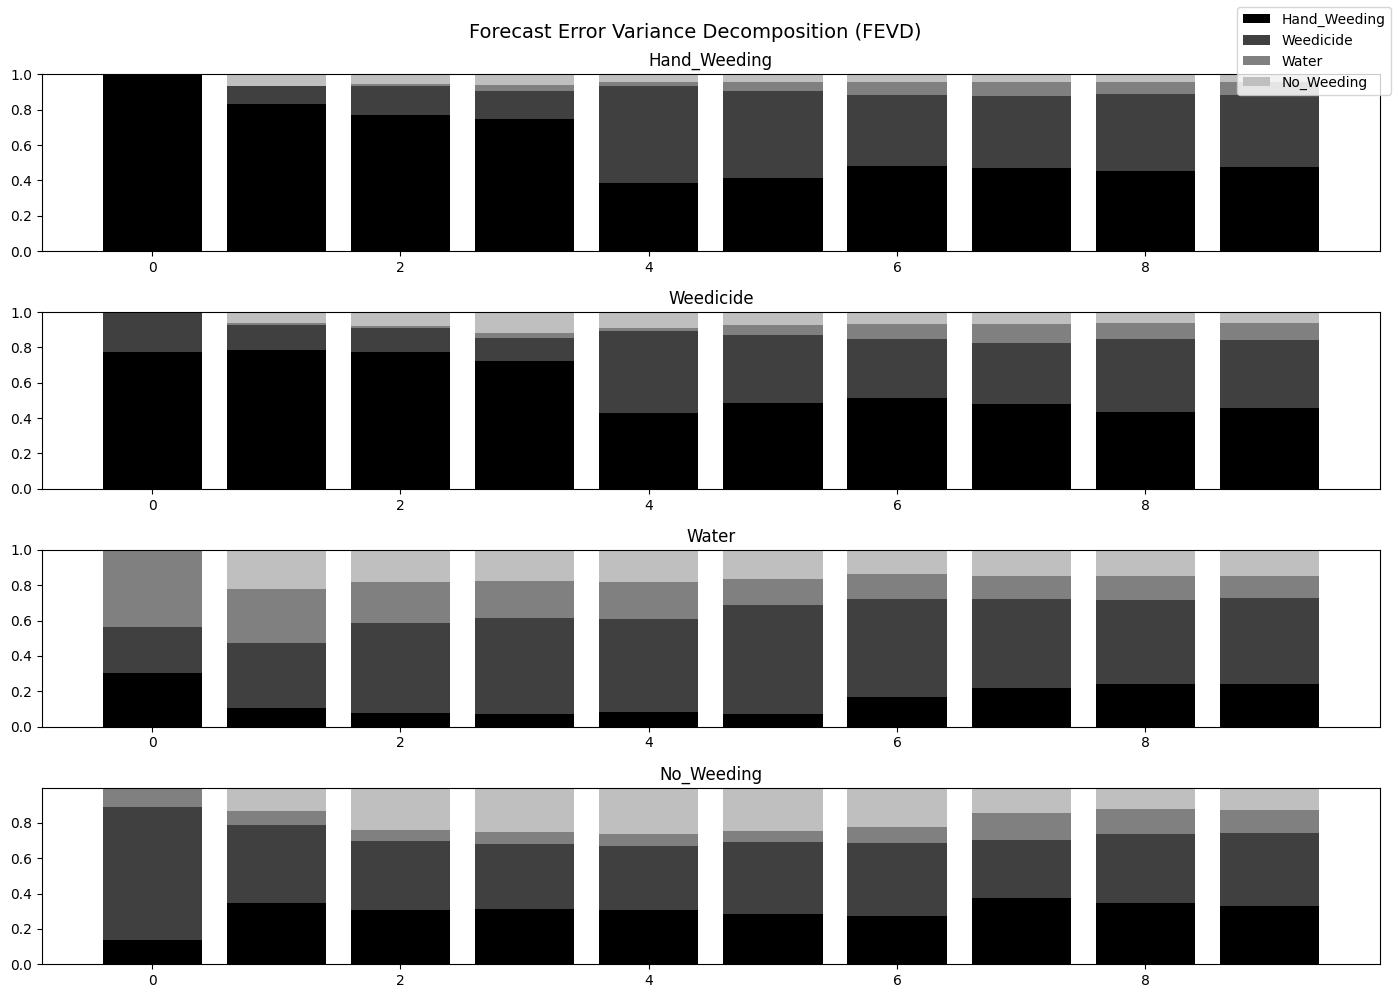

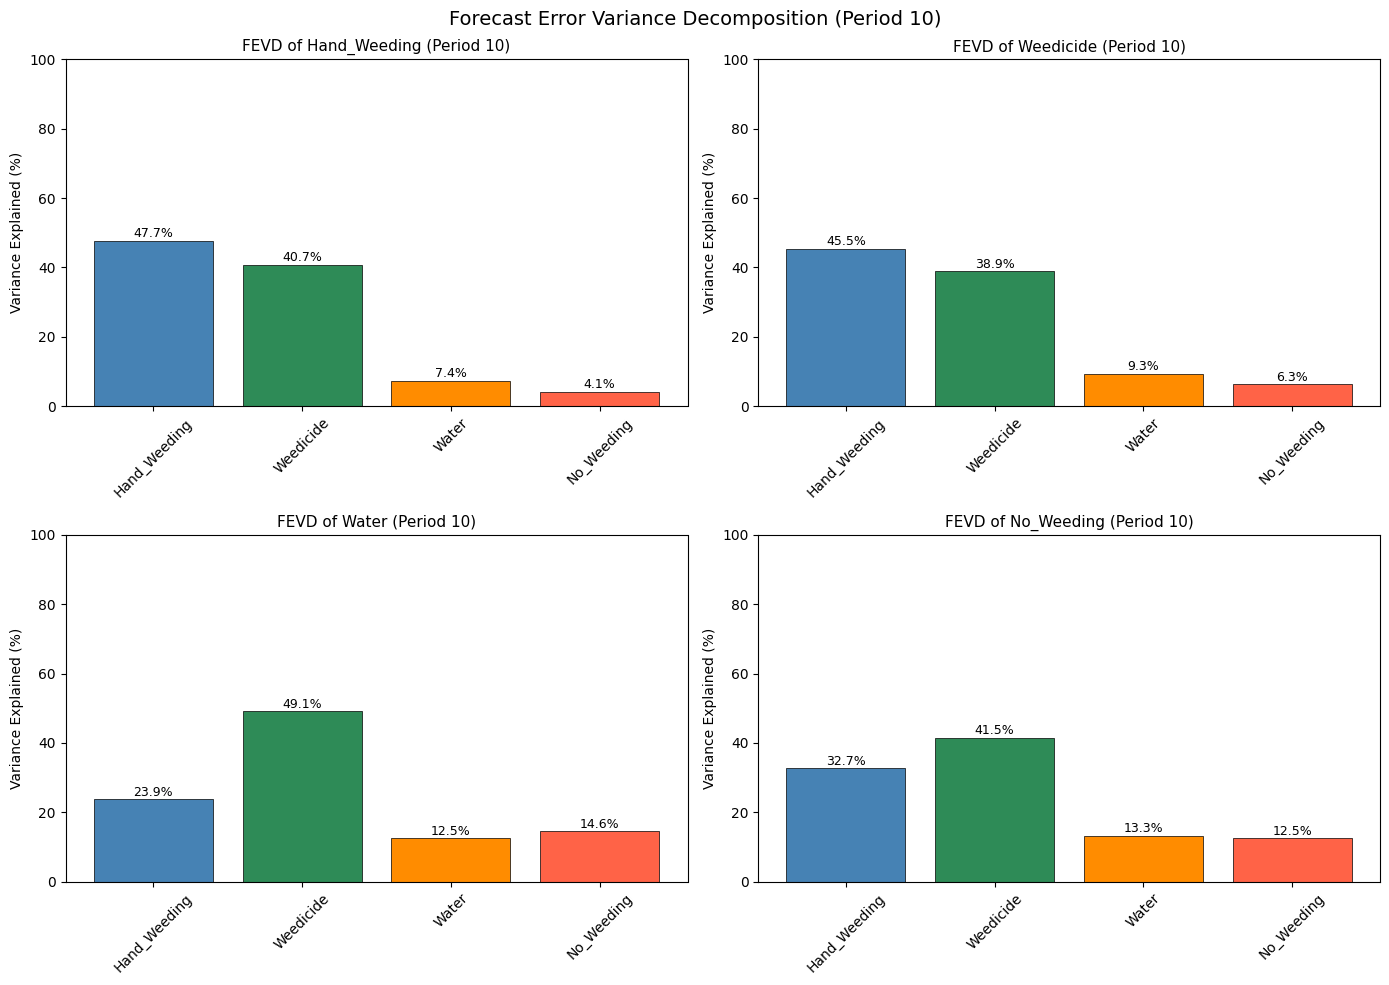

In [20]:
# =========================================================
# 4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)
# =========================================================

print("\n" + "="*60)
print("4. FORECAST ERROR VARIANCE DECOMPOSITION (FEVD)")
print("="*60)

fevd_periods = 10

# Compute FEVD
fevd = var_result.fevd(fevd_periods)

print("FEVD: shows what % of each variable's forecast")
print("error variance is explained by each variable.\n")

# Extract FEVD array
fevd_results = fevd.decomp

print("FEVD Shape:", fevd_results.shape)

# =========================================================
# FEVD TABLES
# =========================================================

for i, col in enumerate(df.columns):

    print(f"\n{'-'*50}")
    print(f"FEVD for {col}")
    print(f"{'-'*50}")

    fevd_df = pd.DataFrame(
        fevd_results[i, :, :],   # Variable i, all periods, all contributors
        columns=df.columns
    )

    fevd_df.index = np.arange(1, len(fevd_df) + 1)
    fevd_df.index.name = "Period"

    print((fevd_df * 100).round(2).to_string())

# =========================================================
# BUILT-IN FEVD PLOT
# =========================================================

fevd.plot(figsize=(14, 10))
plt.suptitle(
    "Forecast Error Variance Decomposition (FEVD)",
    fontsize=14
)
plt.tight_layout()
plt.show()

# =========================================================
# CUSTOM FEVD BAR CHART AT FINAL PERIOD
# =========================================================

n_vars = len(df.columns)

fig, axes = plt.subplots(
    nrows=int(np.ceil(n_vars / 2)),
    ncols=2,
    figsize=(14, 10)
)

axes = np.array(axes).flatten()

colors_fevd = [
    'steelblue',
    'seagreen',
    'darkorange',
    'tomato',
    'purple',
    'gold'
]

# Use last available FEVD period
period_to_plot = min(fevd_periods, fevd_results.shape[1])

for i, col in enumerate(df.columns):

    # FEVD values at selected period
    fevd_at_period = fevd_results[i, period_to_plot - 1, :] * 100

    axes[i].bar(
        df.columns,
        fevd_at_period,
        color=colors_fevd[:n_vars],
        edgecolor='black',
        linewidth=0.5
    )

    axes[i].set_title(
        f"FEVD of {col} (Period {period_to_plot})",
        fontsize=11
    )

    axes[i].set_ylabel("Variance Explained (%)")
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=45)

    for j, val in enumerate(fevd_at_period):
        axes[i].text(
            j,
            val + 1,
            f"{val:.1f}%",
            ha='center',
            fontsize=9
        )

# Remove unused subplots
for k in range(n_vars, len(axes)):
    fig.delaxes(axes[k])

plt.suptitle(
    f"Forecast Error Variance Decomposition (Period {period_to_plot})",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [21]:

# # =========================================================
# # SAVE ALL RESULTS
# # =========================================================
# forecast_restored.to_excel("VAR_Forecasts.xlsx")

# with pd.ExcelWriter("VAR_Full_Analysis.xlsx") as writer:
#     evaluation_df.to_excel(writer, sheet_name='Accuracy',          index=False)
#     gc_df.to_excel(        writer, sheet_name='Granger_Causality', index=False)

#     for i, col in enumerate(df.columns):
#         fevd_df = pd.DataFrame(
#             fevd_results[:, i, :],
#             columns=df.columns
#         )
#         fevd_df.index = fevd_df.index + 1
#         fevd_df.index.name = 'Period'
#         fevd_df.to_excel(writer, sheet_name=f'FEVD_{col[:10]}')

# print("\nAll results saved to VAR_Full_Analysis.xlsx")
# print("Forecasts saved to VAR_Forecasts.xlsx")
# print("\nDone.")